## IMPORT

In [23]:
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display_html
import numpy as np
import datetime as dt
import plotly.graph_objects as go

## PATH

In [24]:
# root directory to access data from notebook folder
ROOT = Path.cwd().parent
# data path
data_path = ROOT / 'data'

## READ DATA

In [25]:
# load the import dataset
df = pd.read_csv(data_path / 'Standard Report - Imports.csv')
df = df.iloc[:, :3]

# eliminate ',' from numbers and convert to datetime
df['export_value'] = df['export_value'].str.replace(',', '').astype(int)
df['Time'] = pd.to_datetime(df['Time']).dt.date

C:\Users\Leonardo\AppData\Local\Temp\ipykernel_31688\4069091096.py:7: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [26]:
# pivot the df to long format
df2 = pd.pivot(df, index='Time', columns='Country', values='export_value')
# df2.index = pd.to_datetime(df2.index.str.strip(), format = 'mixed').date

In [27]:
# check for na
df2.isna().sum()

Country
APEC - Asia Pacific Economic Co-operation           0
ASEAN - Association of Southeast Asian Nations      0
Africa                                             29
Albania                                           238
Andorra                                           239
                                                 ... 
United Arab Emirates                              170
United Kingdom                                      0
Uruguay                                           238
Venezuela                                         237
Vietnam                                            92
Length: 186, dtype: int64

In [28]:
# for vietnam some dates are missing untill 2012
df2.loc[df2['Vietnam'].isna()]

Country,APEC - Asia Pacific Economic Co-operation,ASEAN - Association of Southeast Asian Nations,Africa,Albania,Andorra,Antigua and Barbuda,Argentina,Armenia,Asia,Australia,...,Turks and Caicos Islands,Twenty Latin American Republics,US Trade Agreements Partners,Uganda,Ukraine,United Arab Emirates,United Kingdom,Uruguay,Venezuela,Vietnam
Time,,,,,,,,,,,,,,,,,,,,,
2002-01-01,51441468.0,16552392.0,3958.0,NaN,NaN,NaN,NaN,NaN,43643679.0,718276.0,...,NaN,6504829.0,12447954.0,NaN,NaN,NaN,1267226.0,NaN,NaN,NaN
2002-02-01,54831260.0,14467482.0,3000.0,NaN,NaN,NaN,4000.0,NaN,46439460.0,196732.0,...,NaN,7661671.0,13182790.0,NaN,NaN,NaN,1473030.0,NaN,NaN,NaN
2002-03-01,68067040.0,21142523.0,17344.0,NaN,NaN,NaN,NaN,NaN,56138366.0,1067101.0,...,NaN,8482007.0,16067221.0,NaN,NaN,NaN,2156392.0,NaN,NaN,NaN
2002-04-01,82342197.0,22931002.0,2500.0,NaN,NaN,NaN,19500.0,NaN,70829355.0,677377.0,...,NaN,8079599.0,16693668.0,NaN,NaN,NaN,4590690.0,NaN,NaN,NaN
2002-05-01,104939726.0,48883775.0,9333.0,NaN,NaN,NaN,NaN,NaN,92194599.0,698001.0,...,NaN,10476344.0,19269622.0,NaN,NaN,NaN,1745696.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-07-01,307122973.0,51142854.0,166421.0,NaN,NaN,NaN,26450.0,NaN,262755044.0,109186.0,...,NaN,44932645.0,56616870.0,NaN,NaN,NaN,1878652.0,NaN,NaN,NaN
2010-10-01,361505256.0,57162069.0,18550.0,NaN,NaN,NaN,69040.0,NaN,312145197.0,39612.0,...,NaN,52026992.0,78174052.0,NaN,NaN,NaN,2320168.0,NaN,NaN,NaN
2010-12-01,454622436.0,49250859.0,100313.0,NaN,NaN,NaN,37962.0,NaN,407564883.0,81171.0,...,NaN,59648614.0,87066862.0,NaN,34800.0,NaN,2468117.0,NaN,NaN,NaN


In [29]:
# create the regions for our analysis
df2['china'] = df2[['China', 'Hong Kong']].sum(axis=1)
df2['europe'] = df2[['France', 'Germany', 'Italy', 'Netherlands']].sum(axis=1)
df2['jp_kr'] = df2[['Japan', 'Korea, South']].sum(axis=1)
df2['SEA'] = df2[['Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam']].sum(axis=1)
df2['taiwan'] = df2['Taiwan']

In [32]:
# create the normalized df 
df_norm = df2[['china', 'europe', 'jp_kr', 'SEA', 'taiwan']].copy()

In [33]:
# calculate the total imports cominh from the selected regions
df_norm['total'] = df_norm[['china', 'europe', 'jp_kr', 'SEA', 'taiwan']].sum(axis = 1)

In [34]:
# compute relative market share
df_norm['china'] = df_norm['china'] / df_norm['total']
df_norm['europe'] = df_norm['europe'] / df_norm['total']
df_norm['jp_kr'] = df_norm['jp_kr'] / df_norm['total']
df_norm['SEA'] = df_norm['SEA'] / df_norm['total']
df_norm['taiwan'] = df_norm['taiwan'] / df_norm['total']

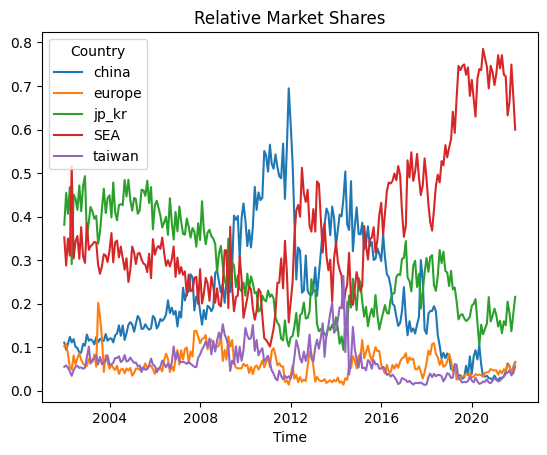

In [35]:
# plot
df_norm[['china', 'europe', 'jp_kr', 'SEA', 'taiwan']].plot()
plt.title('Relative Market Shares')
plt.show()

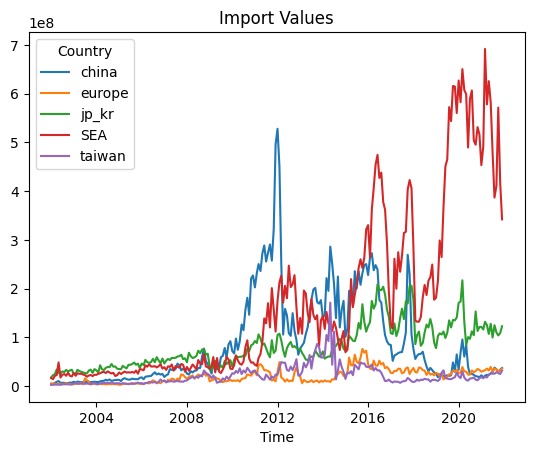

In [36]:
df2[['china', 'europe', 'jp_kr', 'SEA', 'taiwan']].plot()
plt.title('Import Values')
plt.show()

In [37]:
export_data = df2[['china', 'europe', 'jp_kr', 'SEA', 'taiwan']]

In [38]:
# function to plot the values between given dates using plotly to check data integrity
def plot_regions(df, start_date=None, end_date=None):
    # date filters
    if start_date is not None:
        df = df[df.index >= pd.to_datetime(start_date).date()]
    if end_date is not None:
        df = df[df.index <= pd.to_datetime(end_date).date()]

    # figure
    fig = go.Figure()
    # add the line for each region
    for col in df.columns:
        fig.add_trace(go.Scatter(x=df.index, y=df[col], name=col, mode='lines+markers'))
    # add titles and format
    fig.update_layout(
        title=f'Monthly Exports by Region',
        xaxis_title='Date',
        yaxis_title='Export Value (USD)',
        width=1000,
        height=600,
        legend_title='Region',
        hovermode='x unified'
    )
    # plot figure
    fig.show()


In [39]:
# plot the absolute values
plot_regions(df2[['china', 'europe', 'jp_kr', 'SEA', 'taiwan']], '2010-01-01', '2020-12-01')

## EXPORT

In [40]:
# select the relevant columns and rename them for the modelling part
df_abs = df2[['china', 'jp_kr', 'SEA', 'taiwan']].rename(
    columns= {
        'china' : 'China',
        'jp_kr' : 'JP+KR',
        'SEA' : 'SoutheastAsia',
        'taiwan' : 'Taiwan'
    }
)

df_norm = df_norm.rename(
    columns= {
        'china' : 'China',
        'europe' : 'Europe',
        'jp_kr' : 'JP+KR',
        'SEA' : 'SoutheastAsia',
        'taiwan' : 'Taiwan'
    }
)

In [ ]:
# export to csv (commented to avoid file overwriting)
# df_norm.to_csv(data_path / 'dati_normalizzati.csv')
# df_abs.to_csv(data_path / 'dati_assoluti.csv')